In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,12,1


In [13]:
features = df[["Quantity", "Price", "TotalPrice"]]

In [14]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

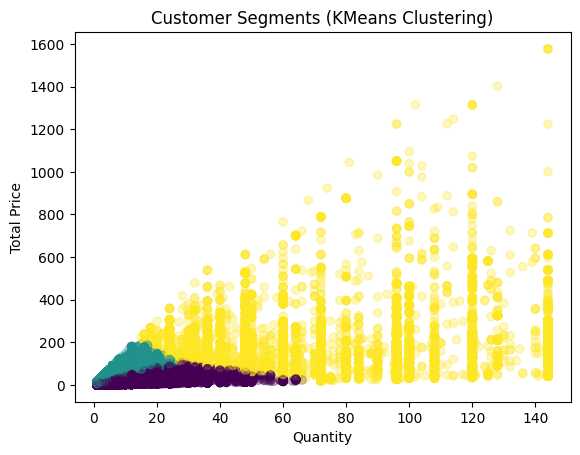

In [18]:
plt.scatter(df["Quantity"], df["TotalPrice"], c=df["Cluster"], alpha=0.3)
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.title("Customer Segments (KMeans Clustering)")
plt.show()

In [17]:
df.groupby("Cluster")[["Quantity", "Price", "TotalPrice"]].mean()

,Quantity,Price,TotalPrice
Cluster,,,
0,8.848427,1.806291,12.595680
1,3.386206,7.387538,23.261371
2,77.363397,2.214721,138.372639


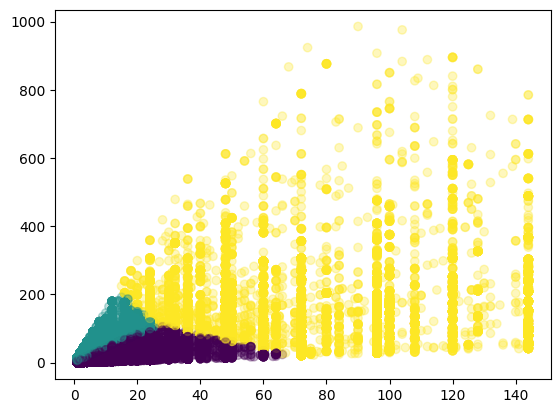

In [19]:
filtered = df[df["TotalPrice"] < 1000]
plt.scatter(filtered["Quantity"], filtered["TotalPrice"], c=filtered["Cluster"], alpha=0.3)
plt.show()